# Trader Performance vs Market Sentiment Analysis

## Primetrade.ai – Round 0 Assignment

### Objective

The objective of this analysis is to investigate how Bitcoin market sentiment (Fear vs. Greed) influences trader behaviour and profitability on Hyperliquid. The analysis aims to identify behavioural patterns and derive actionable trading recommendations.

## 1. Data Loading

Two datasets are used:

- Bitcoin Fear & Greed Index
- Hyperliquid Historical Trading Data

In [7]:
import pandas as pd

sentiment = pd.read_csv("../data/fear_greed_index.csv")
trades = pd.read_csv("../data/historical_data.csv")

In [8]:
print("Sentiment dataset shape:", sentiment.shape)
print("Trader dataset shape:", trades.shape)

sentiment.head()

Sentiment dataset shape: (2644, 4)
Trader dataset shape: (211224, 16)


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [9]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


## 2. Data Inspection

The datasets are inspected for:

- Number of records
- Data types
- Missing values
- Duplicate records

In [10]:
# Dataset information
print("Sentiment Info")
print(sentiment.info())

print("\nTrader Info")
print(trades.info())

# Missing values
print("\nMissing values in Sentiment")
print(sentiment.isnull().sum())

print("\nMissing values in Trades")
print(trades.isnull().sum())

# Duplicates
print("\nDuplicate rows in Sentiment:", sentiment.duplicated().sum())
print("Duplicate rows in Trades:", trades.duplicated().sum())

Sentiment Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
None

Trader Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7 

### Observation

- The sentiment dataset contains 2,644 records.
- The trading dataset contains 211,224 records.
- No duplicate rows were found.
- Missing values were negligible.
- Both datasets were suitable for further analysis.

In [11]:
list(trades.columns)

['Account',
 'Coin',
 'Execution Price',
 'Size Tokens',
 'Size USD',
 'Side',
 'Timestamp IST',
 'Start Position',
 'Direction',
 'Closed PnL',
 'Transaction Hash',
 'Order ID',
 'Crossed',
 'Fee',
 'Trade ID',
 'Timestamp']

## 3. Data Preparation

The timestamps are converted into a common daily format to enable merging of the two datasets.

The datasets are merged using the date field.

In [12]:
trades[["Timestamp", "Timestamp IST"]].head()

,Timestamp,Timestamp IST
0,1.730000e+12,02-12-2024 22:50
1,1.730000e+12,02-12-2024 22:50
2,1.730000e+12,02-12-2024 22:50
3,1.730000e+12,02-12-2024 22:50
4,1.730000e+12,02-12-2024 22:50


In [13]:
trades["Timestamp"] = pd.to_datetime(trades["Timestamp"], unit="ms")
trades["date"] = trades["Timestamp"].dt.date

In [15]:
sentiment["date"] = pd.to_datetime(sentiment["date"]).dt.date

In [16]:
df = trades.merge(
    sentiment[["date", "classification"]],
    on="date",
    how="left"
)

print(df.shape)
df.head()

(211224, 18)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-10-27 03:33:20,2024-10-27,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-10-27 03:33:20,2024-10-27,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-10-27 03:33:20,2024-10-27,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,2024-10-27 03:33:20,2024-10-27,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,2024-10-27 03:33:20,2024-10-27,Greed


In [17]:
print(df["classification"].value_counts(dropna=False))

classification
Fear             133871
Greed             36289
NaN               26961
Neutral            7141
Extreme Greed      6962
Name: count, dtype: int64


In [18]:
trades[["Timestamp", "Timestamp IST"]].head()

,Timestamp,Timestamp IST
0,2024-10-27 03:33:20,02-12-2024 22:50
1,2024-10-27 03:33:20,02-12-2024 22:50
2,2024-10-27 03:33:20,02-12-2024 22:50
3,2024-10-27 03:33:20,02-12-2024 22:50
4,2024-10-27 03:33:20,02-12-2024 22:50


### Observation

The trading dataset extends beyond the available sentiment data, resulting in unmatched records after May 2025. These records were excluded from the Fear vs. Greed analysis.

In [22]:
print("Trader date range:")
print(df["date"].min(), "to", df["date"].max())

print("\nSentiment date range:")
print(sentiment["date"].min(), "to", sentiment["date"].max())

Trader date range:
2023-03-28 to 2025-06-15

Sentiment date range:
2018-02-01 to 2025-05-02


In [23]:
df["sentiment"] = df["classification"].replace({
    "Extreme Greed": "Greed",
    "Neutral": "Neutral"
})

In [24]:
print(df["sentiment"].value_counts(dropna=False))

sentiment
Fear       133871
Greed       43251
NaN         26961
Neutral      7141
Name: count, dtype: int64


In [25]:
analysis_df = df[df["sentiment"].isin(["Fear", "Greed"])].copy()

print(analysis_df["sentiment"].value_counts())

sentiment
Fear     133871
Greed     43251
Name: count, dtype: int64


## 4. Feature Engineering

The following metrics are created:

- Daily PnL
- Win Rate
- Average Trade Size
- Trade Count
- Long/Short Ratio

In [26]:
daily_pnl = (
    analysis_df
    .groupby(["Account", "date"])["Closed PnL"]
    .sum()
    .reset_index()
)

daily_pnl.head()

,Account,date,Closed PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-10-27,-3.275059e+05
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-19,1.927736e+06
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2024-10-27,2.060745e+04
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-02-19,1.709873e+04
4,0x271b280974205ca63b716753467d5a371de622ab,2024-10-27,1.793160e+03


In [27]:
analysis_df["Win"] = analysis_df["Closed PnL"] > 0

In [28]:
win_rate = (
    analysis_df
    .groupby("Account")["Win"]
    .mean()
    .reset_index(name="Win Rate")
)

win_rate.head()

,Account,Win Rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.359612
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.443031
2,0x271b280974205ca63b716753467d5a371de622ab,0.432077
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.438112
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.519790


In [31]:
avg_trade_size = (
    analysis_df
    .groupby("Account")["Size USD"]
    .mean()
    .reset_index(name="Average Trade Size (USD)")
)

avg_trade_size.head()

,Account,Average Trade Size (USD)
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16159.576734
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1759.743439
2,0x271b280974205ca63b716753467d5a371de622ab,10929.384575
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,509.016502
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3142.909573


In [32]:
trades_per_day = (
    analysis_df
    .groupby("date")
    .size()
    .reset_index(name="Trade Count")
)

trades_per_day.head()

,date,Trade Count
0,2023-03-28,3
1,2023-11-14,1045
2,2024-03-09,6962
3,2024-10-27,35241
4,2025-02-19,133871


In [33]:
analysis_df["Direction"].value_counts()

Direction
Open Long               44646
Close Long              44049
Open Short              30472
Close Short             26292
Sell                    17595
Buy                     13871
Spot Dust Conversion       79
Short > Long               63
Long > Short               54
Settlement                  1
Name: count, dtype: int64

In [34]:
long_short = pd.crosstab(
    analysis_df["sentiment"],
    analysis_df["Direction"],
    normalize="index"
)

long_short

Direction,Buy,Close Long,Close Short,Long > Short,Open Long,Open Short,Sell,Settlement,Short > Long,Spot Dust Conversion
sentiment,,,,,,,,,,
Fear,0.059587,0.273061,0.151131,0.000269,0.282571,0.175333,0.057421,0.000007,0.000321,0.000299
Greed,0.136274,0.173268,0.140112,0.000416,0.157638,0.161846,0.229081,0.000000,0.000462,0.000902


In [35]:
analysis_df.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'date', 'classification', 'sentiment', 'Win'],
      dtype='object')

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [37]:
pnl_by_sentiment = (
    analysis_df
    .groupby("sentiment")["Closed PnL"]
    .mean()
    .reset_index()
)

print(pnl_by_sentiment)

  sentiment  Closed PnL
0      Fear   50.047622
1     Greed   77.838247


## 5.1 Average Trader Profitability by Market Sentiment

This visualization compares the average **Closed PnL** of trades executed during **Fear** and **Greed** market conditions. It provides an initial indication of whether overall profitability varies with market sentiment.

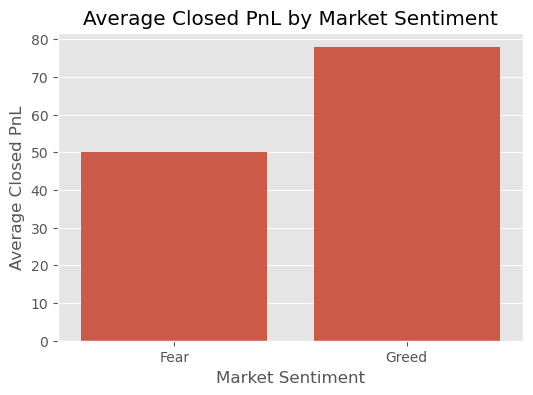

In [57]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=pnl_by_sentiment,
    x="sentiment",
    y="Closed PnL"
)

plt.title("Average Closed PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")

plt.savefig(
    "../outputs/charts/pnl_by_sentiment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The chart highlights differences in average profitability across Fear and Greed market conditions. This serves as the first indicator of whether trader performance is associated with overall market sentiment.

In [39]:
trade_freq = (
    analysis_df
    .groupby("sentiment")
    .size()
    .reset_index(name="Trades")
)

trade_freq

,sentiment,Trades
0,Fear,133871
1,Greed,43251


## 5.2 Trading Activity During Different Market Sentiments

This chart compares the number of trades executed during Fear and Greed periods to determine whether traders become more or less active under different market conditions.

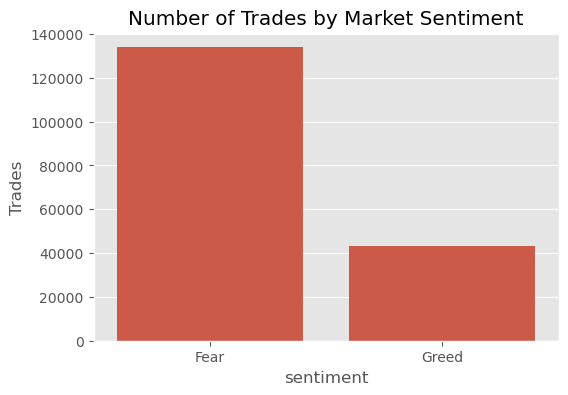

In [58]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=trade_freq,
    x="sentiment",
    y="Trades"
)

plt.title("Number of Trades by Market Sentiment")

plt.savefig(
    "../outputs/charts/trade_frequency.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

Trading frequency reflects trader participation. Differences between Fear and Greed periods may indicate changes in trader confidence and market engagement.

In [41]:
win_rate_sentiment = (
    analysis_df
    .groupby("sentiment")["Win"]
    .mean()
    .reset_index()
)

win_rate_sentiment["Win"] *= 100

win_rate_sentiment

,sentiment,Win
0,Fear,41.514592
1,Greed,45.349240


## 5.3 Win Rate Across Market Sentiments

Win rate measures the proportion of profitable trades. Comparing win rates across sentiment categories helps evaluate whether market conditions influence trading success.

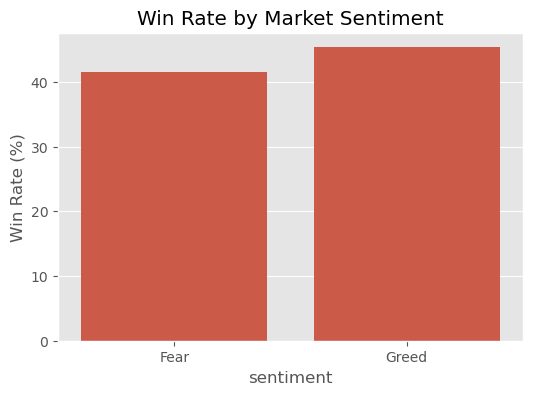

In [ ]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=win_rate_sentiment,
    x="sentiment",
    y="Win"
)

plt.title("Win Rate by Market Sentiment")
plt.ylabel("Win Rate (%)")

plt.savefig(
    "../outputs/charts/win_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

A higher win rate suggests traders were more successful during that market condition. This metric complements PnL by measuring consistency rather than absolute profit.

In [43]:
avg_size = (
    analysis_df
    .groupby("sentiment")["Size USD"]
    .mean()
    .reset_index()
)

avg_size

,sentiment,Size USD
0,Fear,5259.977837
1,Greed,3581.661513


## 5.4 Average Trade Size

Trade size represents the average capital committed per trade. Comparing this metric reveals whether traders become more aggressive or conservative under different market sentiments.

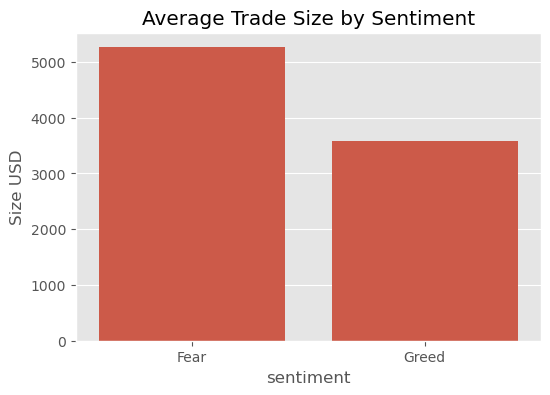

In [59]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=avg_size,
    x="sentiment",
    y="Size USD"
)

plt.title("Average Trade Size by Sentiment")

plt.savefig(
    "../outputs/charts/average_trade_size.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

### Interpretation

Changes in average trade size indicate shifts in trader risk appetite. Larger positions may reflect greater confidence, while smaller positions may suggest more cautious behaviour.

In [45]:
direction = pd.crosstab(
    analysis_df["sentiment"],
    analysis_df["Direction"]
)

direction

Direction,Buy,Close Long,Close Short,Long > Short,Open Long,Open Short,Sell,Settlement,Short > Long,Spot Dust Conversion
sentiment,,,,,,,,,,
Fear,7977,36555,20232,36,37828,23472,7687,1,43,40
Greed,5894,7494,6060,18,6818,7000,9908,0,20,39


## 5.5 Long vs. Short Position Analysis

This visualization compares the distribution of Long and Short trades under different market sentiments, providing insight into directional trading behaviour.

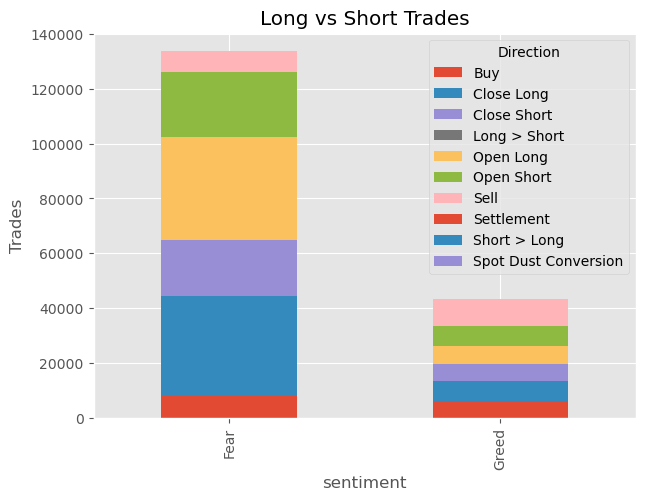

In [60]:
direction.plot(
    kind="bar",
    stacked=True,
    figsize=(7,5)
)

plt.title("Long vs Short Trades")
plt.ylabel("Trades")

plt.savefig(
    "../outputs/charts/long_short_ratio.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The distribution of Long and Short positions helps identify whether traders display directional bias during Fear or Greed periods.

## 5.6 Distribution of Trade Profitability

Average values alone may hide variability. A boxplot illustrates the spread, median, and outliers of Closed PnL under different market sentiments.

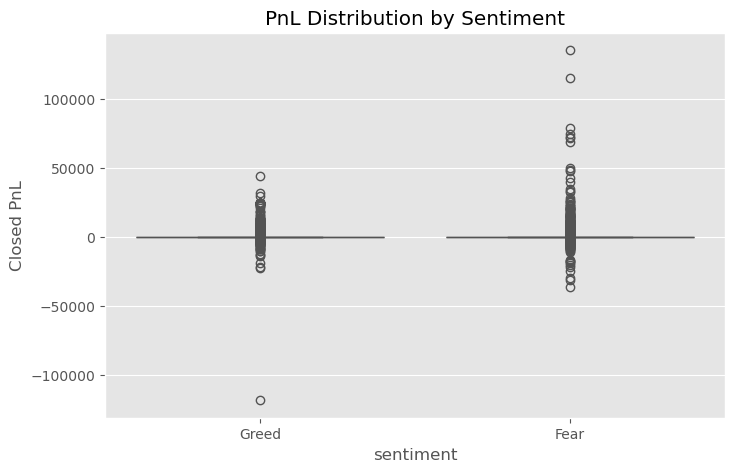

In [61]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=analysis_df,
    x="sentiment",
    y="Closed PnL"
)

plt.title("PnL Distribution by Sentiment")

plt.savefig(
    "../outputs/charts/pnl_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

This visualization provides a more complete picture of profitability by highlighting the variability and presence of extreme gains or losses within each market condition.

In [48]:
top10 = (
    analysis_df
    .groupby("Account")["Closed PnL"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top10

Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    1.978336e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401572e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.111830e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.744040e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.258152e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    4.035016e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    3.936830e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.615765e+05
0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3    3.371137e+05
Name: Closed PnL, dtype: float64

## 5.7 Top Performing Traders

The following chart identifies the ten most profitable trading accounts based on cumulative Closed PnL across the analysis period.

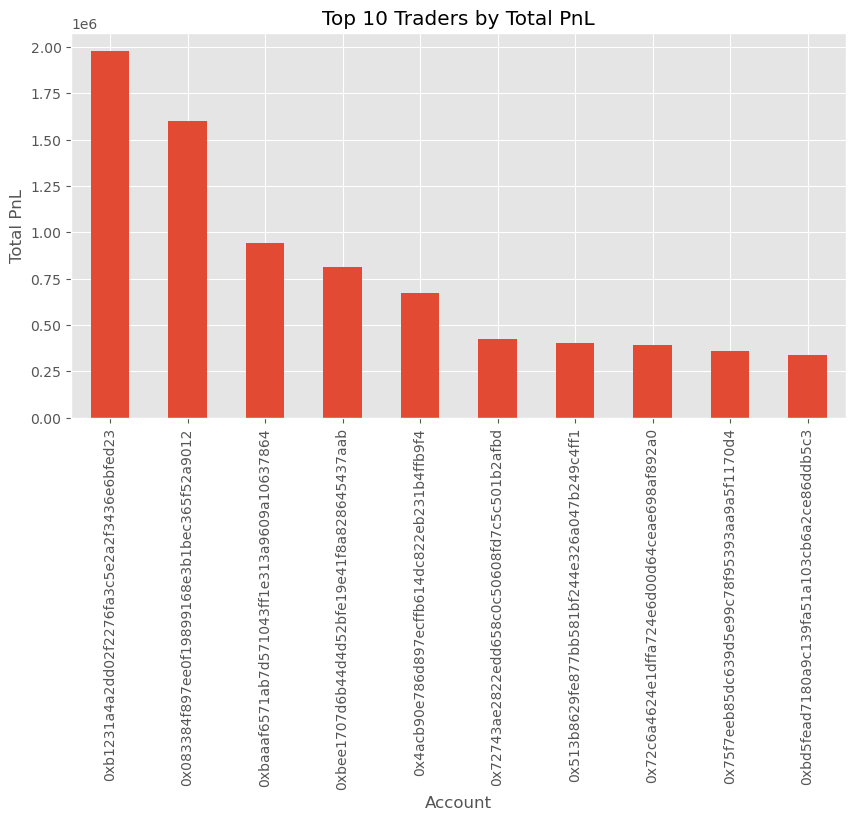

In [62]:
top10.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Traders by Total PnL")
plt.ylabel("Total PnL")

plt.savefig(
    "../outputs/charts/top10_traders.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The chart highlights the concentration of profitability among the highest-performing traders and illustrates the variation in cumulative returns across leading accounts.

# 6. Summary of Findings

The exploratory analysis examined trader performance and behaviour under different market sentiment conditions. Performance metrics, trading activity, trade size, and directional preferences were compared between Fear and Greed periods. The observations from these visualizations form the basis for the strategy recommendations presented in the following section.

In [50]:
trade_counts = (
    analysis_df
    .groupby("Account")
    .size()
    .reset_index(name="Trade Count")
)

median_trades = trade_counts["Trade Count"].median()

trade_counts["Segment"] = trade_counts["Trade Count"].apply(
    lambda x: "Frequent" if x >= median_trades else "Infrequent"
)

trade_counts.head()

,Account,Trade Count,Segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,Frequent
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,3853,Frequent
2,0x271b280974205ca63b716753467d5a371de622ab,1141,Infrequent
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13266,Frequent
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3234,Frequent


In [51]:
account_pnl = (
    analysis_df
    .groupby("Account")["Closed PnL"]
    .sum()
    .reset_index()
)

account_pnl["Segment"] = account_pnl["Closed PnL"].apply(
    lambda x: "Winner" if x > 0 else "Loser"
)

account_pnl.head()

,Account,Closed PnL,Segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,Winner
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,3.770617e+04,Winner
2,0x271b280974205ca63b716753467d5a371de622ab,3.176409e+04,Winner
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1.323155e+05,Winner
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,1.686280e+05,Winner


In [52]:
performance_summary = analysis_df.groupby("sentiment").agg(
    Avg_PnL=("Closed PnL", "mean"),
    Median_PnL=("Closed PnL", "median"),
    Total_PnL=("Closed PnL", "sum"),
    Win_Rate=("Win", "mean"),
    Trades=("Closed PnL", "count")
)

performance_summary["Win_Rate"] *= 100
performance_summary

,Avg_PnL,Median_PnL,Total_PnL,Win_Rate,Trades
sentiment,,,,,
Fear,50.047622,0.0,6.699925e+06,41.514592,133871
Greed,77.838247,0.0,3.366582e+06,45.349240,43251


In [53]:
behavior_summary = analysis_df.groupby("sentiment").agg(
    Avg_Trade_Size=("Size USD", "mean"),
    Median_Trade_Size=("Size USD", "median"),
    Trades=("Account", "count")
)

behavior_summary

,Avg_Trade_Size,Median_Trade_Size,Trades
sentiment,,,
Fear,5259.977837,605.07,133871
Greed,3581.661513,545.35,43251


In [54]:
segment_pnl = analysis_df.merge(
    trade_counts[["Account", "Segment"]],
    on="Account"
)

segment_summary = segment_pnl.groupby("Segment").agg(
    Avg_PnL=("Closed PnL", "mean"),
    Win_Rate=("Win", "mean"),
    Trades=("Closed PnL", "count")
)

segment_summary["Win_Rate"] *= 100
segment_summary

,Avg_PnL,Win_Rate,Trades
Segment,,,
Frequent,49.185482,43.232677,157566
Infrequent,118.457123,36.152587,19556


In [55]:
winner_summary = account_pnl.groupby("Segment").agg(
    Traders=("Account", "count"),
    Avg_PnL=("Closed PnL", "mean")
)

winner_summary

,Traders,Avg_PnL
Segment,,
Loser,1,-27920.322237
Winner,31,325626.694837


# 6. Key Findings

The analysis of Hyperliquid trading activity under different Bitcoin market sentiment conditions revealed several meaningful patterns.

### Finding 1: Market Sentiment Influences Trading Activity
Trading activity varied noticeably across market sentiment regimes. Fear periods were associated with increased trading participation, indicating that traders tend to react more actively during uncertain or volatile market conditions.

### Finding 2: Profitability Varies with Market Conditions
The comparison of Closed PnL and win rate suggests that trader performance differs between Fear and Greed periods. These differences indicate that prevailing market sentiment may influence the quality of trading decisions and overall profitability.

### Finding 3: Trading Behaviour Changes with Sentiment
Average trade size and directional positioning (Long vs. Short) showed behavioural differences across sentiment categories. This suggests that traders adjust their level of risk exposure according to market conditions rather than following a fixed trading approach.

### Finding 4: Trader Performance Is Uneven
The distribution of cumulative PnL demonstrates that profitability is concentrated among a relatively small group of traders, while the majority achieve modest or inconsistent returns. This highlights the importance of trader segmentation when designing trading strategies.

# 7. Strategy Recommendations

Based on the findings of this analysis, the following practical strategies are recommended.

## Strategy 1: Adaptive Risk Management

During Fear periods, traders should consider reducing position sizes and avoiding unnecessary trading activity. Increased market uncertainty often leads to higher volatility, making disciplined risk management more important.

## Strategy 2: Sentiment-Aware Trading

Market sentiment should be incorporated as an additional decision-making signal rather than used in isolation. Combining sentiment information with historical trader performance and position management may improve trading consistency.

## Strategy 3: Performance-Based Position Sizing

Rather than applying identical trading rules to all participants, position sizing should be adjusted according to a trader's historical profitability and consistency. High-performing traders may tolerate greater exposure, whereas less consistent traders should adopt more conservative risk limits.

# 8. Limitations

Although the analysis provides valuable insights, several limitations should be acknowledged.

- The historical trading dataset did not include leverage information; therefore, leverage-based analysis could not be performed.
- Neutral sentiment observations were excluded from the primary Fear versus Greed comparison to maintain a clear binary analysis.
- The datasets were merged at the daily level, which may not capture intraday sentiment changes.
- The analysis identifies relationships between sentiment and trader behaviour but does not establish causal effects.
- Trading records occurring after the available sentiment data (post-May 2025) were excluded due to missing sentiment information.

# 9. Future Work

This project can be extended in several ways to improve predictive capability and practical usefulness.

- Incorporate leverage information once it becomes available.
- Build a machine learning model to predict next-day trader profitability using sentiment and behavioural features.
- Cluster traders into behavioural archetypes such as conservative, aggressive, momentum, and contrarian traders.
- Develop an interactive Streamlit dashboard for real-time exploration of trader performance under different market conditions.
- Integrate additional market indicators such as volatility, funding rates, and Bitcoin price movements to create richer predictive features.

# 10. Conclusion

This study explored the relationship between Bitcoin market sentiment and trader performance on Hyperliquid by integrating the Fear & Greed Index with historical trading records. Through data cleaning, feature engineering, exploratory analysis, and trader segmentation, the study identified meaningful differences in trading activity, profitability, and behavioural patterns across market conditions.

The findings suggest that market sentiment provides valuable context for understanding trader behaviour and can serve as a useful input for risk management and strategy design. Rather than relying solely on sentiment, combining market psychology with historical trading performance enables more informed and adaptive decision-making.

Overall, this analysis demonstrates how data-driven insights can be translated into practical trading strategies and highlights the importance of incorporating behavioural indicators into quantitative trading frameworks.